<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Sun Jul 19 10:35:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

- Automotive Industry: autonomous driving
- Healthcare: tumor detection
- Manufacturing: defect detection

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

Overfitting is when model performs really well on data that it was trained on, but does not perform well on unseen data that it was not trained on.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

We can prevent overfitting by:
- Regularization: penalizes model for really large weight values.

- Dropout: randomly drops out some neurons from each layer, this enables model to learn robust features and prevents relying heavily on specific neurons.

- Increase dataset size: by increasing data size, we enable model to learn more general rules rather than memorizing.

- Data augmentation: by augmenting data, we force model to learn on much larger data distribution and to learn more general features, but also increasing dataset size as well.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_data = MNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = MNIST(root="data", train=False, download=True, transform=ToTensor())

## 6. Visualize at least 5 different samples of the MNIST training dataset.

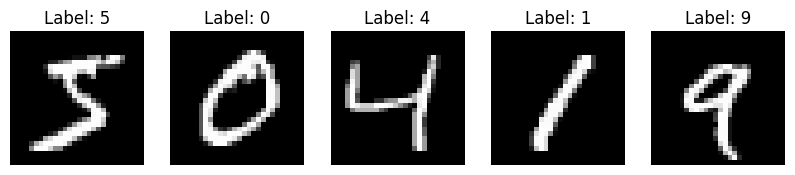

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(5):
  plt.subplot(1, 5, i+1)
  image, label = train_data[i]
  plt.imshow(image.squeeze(), cmap="gray")
  plt.title(f"Label: {label}")
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [6]:
import torch.nn as nn

class MNISTModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [7]:
model_on_gpu = MNISTModel(input_shape=1, hidden_units=10, output_shape=10).to(device)

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_on_gpu.parameters(), lr=0.1)

In [9]:
!pip install torchmetrics

In [10]:
from torchmetrics import Accuracy

accuracy_fn = Accuracy(task="multiclass", num_classes=10).to(device)

In [11]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from tqdm.auto import tqdm

def train_model(
  model: torch.nn.Module,
  train_dataloader: torch.utils.data.DataLoader,
  test_dataloader: torch.utils.data.DataLoader,
  loss_fn: torch.nn.Module,
  optimizer: torch.optim.Optimizer,
  accuracy_fn,
  epochs: int,
  device: torch.device
):
  for epoch in tqdm(range(epochs)):
    ### Training
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(train_dataloader):
      model.train()
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      loss = loss_fn(y_pred, y)

      train_loss += loss
      train_acc += accuracy_fn(y_pred.argmax(dim=1), y)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    ### Testing
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
      for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        test_pred = model(X)

        loss = loss_fn(test_pred, y)
        test_acc += accuracy_fn(test_pred.argmax(dim=1), y)
        test_loss += loss

      test_loss /= len(test_dataloader)
      test_acc /= len(test_dataloader)
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Accuracy: {train_acc:.5f} | Test loss: {test_loss:.5f} | Test Accuracy: {test_acc:.5f}")

In [12]:
from time import time

start_time = time()

train_model(model=model_on_gpu, train_dataloader=train_dataloader, test_dataloader=test_dataloader, epochs=5, device=device, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

end_time = time()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.31275 | Train Accuracy: 0.89487 | Test loss: 0.07775 | Test Accuracy: 0.97684
Epoch: 1 | Train Loss: 0.07647 | Train Accuracy: 0.97587 | Test loss: 0.05993 | Test Accuracy: 0.98223
Epoch: 2 | Train Loss: 0.05904 | Train Accuracy: 0.98167 | Test loss: 0.05360 | Test Accuracy: 0.98243
Epoch: 3 | Train Loss: 0.04942 | Train Accuracy: 0.98468 | Test loss: 0.06248 | Test Accuracy: 0.97983
Epoch: 4 | Train Loss: 0.04387 | Train Accuracy: 0.98645 | Test loss: 0.04992 | Test Accuracy: 0.98293
Total training time: 77.232 seconds


In [13]:
model_on_cpu = MNISTModel(input_shape=1, hidden_units=10, output_shape=10).to("cpu")

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_on_cpu.parameters(), lr=0.1)

In [15]:
accuracy_fn = Accuracy(task="multiclass", num_classes=10).to("cpu")

In [16]:
start_time = time()

train_model(model=model_on_cpu, train_dataloader=train_dataloader, test_dataloader=test_dataloader, epochs=5, device="cpu", loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

end_time = time()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.31449 | Train Accuracy: 0.89515 | Test loss: 0.08048 | Test Accuracy: 0.97274
Epoch: 1 | Train Loss: 0.07401 | Train Accuracy: 0.97708 | Test loss: 0.07525 | Test Accuracy: 0.97404
Epoch: 2 | Train Loss: 0.05764 | Train Accuracy: 0.98227 | Test loss: 0.05048 | Test Accuracy: 0.98393
Epoch: 3 | Train Loss: 0.04946 | Train Accuracy: 0.98432 | Test loss: 0.04463 | Test Accuracy: 0.98413
Epoch: 4 | Train Loss: 0.04288 | Train Accuracy: 0.98640 | Test loss: 0.04852 | Test Accuracy: 0.98433
Total training time: 194.569 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

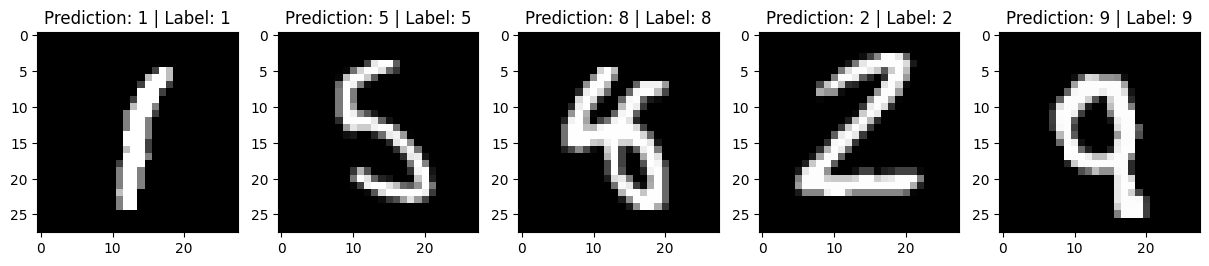

In [17]:
samples = list(test_dataloader)[5:10]
model_on_gpu.eval()
with torch.inference_mode():
  for X, y in samples:
    X, y = X.to(device), y.to(device)
    y_pred = model_on_gpu(X)


plt.figure(figsize=(15, 10))
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(X[i].squeeze().cpu(), cmap="gray")
  plt.title(f"Prediction: {y_pred[i].argmax()} | Label: {y[i]}")

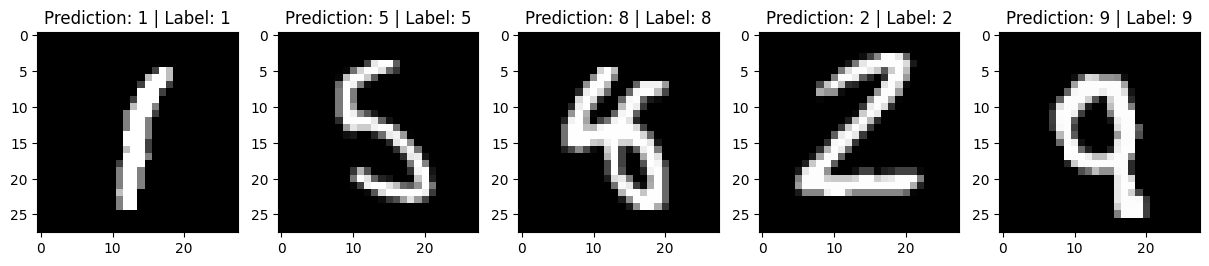

In [18]:
samples = list(test_dataloader)[5:10]
model_on_cpu.eval()
with torch.inference_mode():
  for X, y in samples:
    X, y = X.to("cpu"), y.to("cpu")
    y_pred = model_on_cpu(X)


plt.figure(figsize=(15, 10))
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(X[i].squeeze().cpu(), cmap="gray")
  plt.title(f"Prediction: {y_pred[i].argmax()} | Label: {y[i]}")

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

<Axes: >

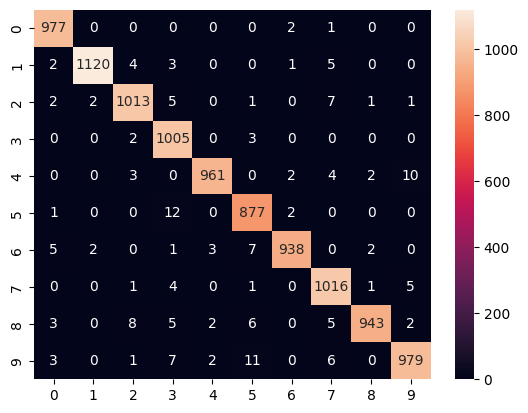

In [19]:
from torchmetrics import ConfusionMatrix
import seaborn as sns

y_true = []
y_pred = []

model_on_gpu.eval()
with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to(device), y.to(device)
    y_pred_ = model_on_gpu(X)
    y_true.extend(y.cpu().numpy())
    y_pred.extend(y_pred_.argmax(dim=1).cpu().numpy())

cm = ConfusionMatrix(task="multiclass", num_classes=10)(torch.tensor(y_pred), torch.tensor(y_true))
cm = cm.numpy()
sns.heatmap(cm, annot=True, fmt="d")

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [20]:
random_tensor = torch.randn(1, 3, 64, 64)
conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=(5, 5))

conv_layer(random_tensor).shape

torch.Size([1, 10, 60, 60])

We can notice that when we increase size of kernel by n, it decreases output height and width by that same number

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [21]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor

train_data = FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_data = FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

In [22]:
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

In [23]:
model_2 = MNISTModel(input_shape=1, hidden_units=10, output_shape=len(train_data.classes)).to(device) # this has same architecture as FashionMNIST model from lectures
model_2

MNISTModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)
accuracy_fn = Accuracy(task="multiclass", num_classes=len(train_data.classes)).to(device)

In [25]:
train_model(model=model_2, train_dataloader=train_dataloader, test_dataloader=test_dataloader, epochs=5, device=device, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.57180 | Train Accuracy: 0.79515 | Test loss: 0.36992 | Test Accuracy: 0.86821
Epoch: 1 | Train Loss: 0.34257 | Train Accuracy: 0.87608 | Test loss: 0.37950 | Test Accuracy: 0.86911
Epoch: 2 | Train Loss: 0.30901 | Train Accuracy: 0.88893 | Test loss: 0.32799 | Test Accuracy: 0.87620
Epoch: 3 | Train Loss: 0.29091 | Train Accuracy: 0.89493 | Test loss: 0.32825 | Test Accuracy: 0.88399
Epoch: 4 | Train Loss: 0.27877 | Train Accuracy: 0.89763 | Test loss: 0.28979 | Test Accuracy: 0.89736


In [26]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

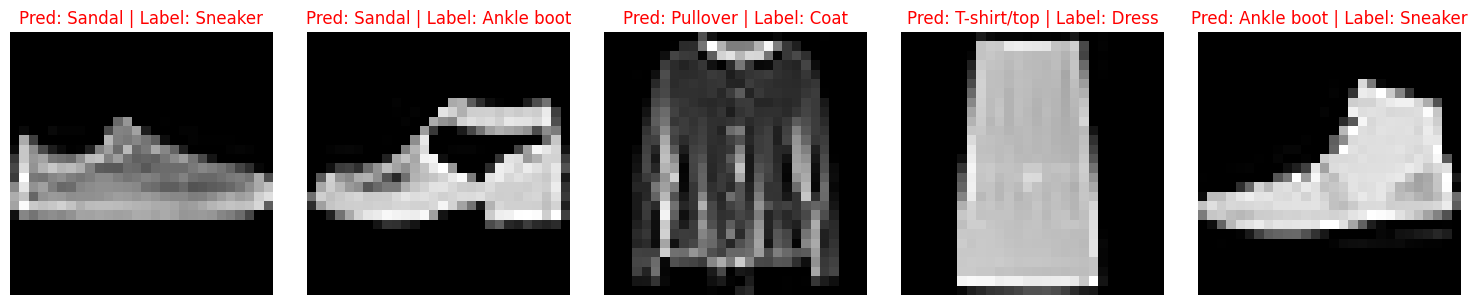

In [27]:
model_2.eval()

num_images_to_show = 5
collected_images, collected_preds, collected_labels = [], [], []

with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to(device), y.to(device)
    y_pred = model_2(X)
    y_pred_labels = y_pred.argmax(dim=1)

    wrong_indices = (torch.not_equal(y, y_pred_labels)).nonzero(as_tuple=True)[0]

    for idx in wrong_indices:
        collected_images.append(X[idx].cpu())
        collected_preds.append(y_pred_labels[idx].cpu().item())
        collected_labels.append(y[idx].cpu().item())

        if len(collected_images) >= num_images_to_show:
            break

    if len(collected_images) >= num_images_to_show:
        break

plt.figure(figsize=(15, 3))
for i in range(num_images_to_show):
  plt.subplot(1, num_images_to_show, i+1)
  plt.imshow(collected_images[i].squeeze(), cmap="gray")

  plt.title(f"Pred: {class_names[collected_preds[i]]} | Label: {class_names[collected_labels[i]]}", color="red")
  plt.axis("off")

plt.tight_layout()
plt.show()

I think we could improve models performance a bit more by adding more representation of lacking classes and similar ones such as sandal and sneaker. As similar classes are harder to distinguish so we need more data of these classes.